# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc365mfc"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.389 0.402 0.41500000000000004 ... 0.6376666666666667 0.6373333333333334 0.637] [0.389 0.402 0.4222727272727273 ... 0.6376666666666666 0.6373333333333333 0.637] [0.389 0.4056363636363637 0.4336153846153846 ... 0.648 0.6373333333333333 0.637] [0.389 0.429 0.469 ... 0.627 0.632 0.637] [0.389 0.402 0.4285 ... 0.6323333333333333 0.6373333333333333 0.637] [0.389 0.402 0.415 ... 0.6376666666666667 0.6373333333333333 0.637]] [[0.3946666666666667 0.4084444444444445 0.4222222222222223 ... 0.6396666666666667 0.6443333333333334 0.649] [0.3946666666666667 0.40844444444444444 0.4293939393939394 ... 0.6396666666666666 0.6443333333333333 0.649] [0.3946666666666667 0.4120303030303031 0.44056410256410267 ... 0.642 0.6443333333333333 0.649] [0.3946666666666667 0.4344583333333334 0.47425000000000006 ... 0.623 0.636 0.649] [0.3946666666666667 0.40844444444444444 0.4352291666666667 ... 0.6313333333333333 0.6443333333333333 0.649] [0.3946666666666667 0.4084444444444445 0.4222222222222222 ... 0.6396666666666667 0.6443333333333333 0.649]] [[0.4195 0.39515000000000006 0.41175 ... 0.6463333333333333 0.6486666666666667 0.651] [0.4195 0.3815 0.41305555555555556 ... 0.6463333333333333 0.6486666666666667 0.651] [0.4195 0.4138181818181818 0.44045454545454543 ... 0.654 0.6486666666666666 0.651] [0.4195 0.45868749999999997 0.49787499999999996 ... 0.679 0.665 0.651] [0.4195 0.42245 0.45034375 ... 0.6626666666666666 0.6486666666666667 0.651] [0.4195 0.4088 0.4254 ... 0.6463333333333333 0.6486666666666667 0.651]] ... [[0.99 0.9941666666666666 0.9983333333333333 ... 1.0788333333333333 1.079 1.083] [0.99 0.9941666666666665 0.9938181818181818 ... 1.1 1.0915 1.083] [0.9899999999999999 0.991909090909091 0.9951339285714286 ... 1.0825 1.0823333333333331 1.083] [0.99 0.9994047619047619 1.0088095238095238 ... 1.0787592592592594 1.0815000000000001 1.083] [0.9899999999999999 0.9941666666666666 1.000952380952381 ... 1.0750185185185186 1.0806666666666667 1.083] [0.99 0.9941666666666666 0.9983333333333332 ... 1.0712777777777778 1.0798333333333332 1.083]] [[0.989 0.9893333333333334 0.9896666666666667 ... 1.06925 1.07275 1.06775] [0.989 0.9893333333333334 0.994501754385965 ... 1.1733333333333331 1.1205416666666665 1.06775] [0.989 0.9917508771929824 1.0017543859649123 ... 1.071 1.06975 1.06775] [0.989 0.9968571428571429 1.0047142857142857 ... 1.0683888888888888 1.0705 1.06775] [0.989 0.9893333333333333 0.9934285714285714 ... 1.0657777777777777 1.07125 1.06775] [0.989 0.9893333333333333 0.9896666666666666 ... 1.0631666666666666 1.072 1.06775]] [[0.9885 0.9873333333333334 0.9861666666666667 ... 1.0616999999999999 1.0623999999999998 1.066] [0.9885 0.9873333333333333 0.9918684210526316 ... 1.059 1.0625 1.066] [0.9885 0.9901842105263158 1.0004210526315789 ... 1.065 1.0651555555555554 1.066] [0.9885 0.9956190476190477 1.002738095238095 ... 1.0614592592592593 1.0644666666666667 1.066] [0.9885 0.9873333333333333 0.9903095238095238 ... 1.0579185185185185 1.0637777777777777 1.066] [0.9885 0.9873333333333334 0.9861666666666666 ... 1.0543777777777776 1.0630888888888888 1.066]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.389 0.402 0.41500000000000004 ... 0.6376666666666667 0.6373333333333334 0.637] [0.389 0.402 0.4222727272727273 ... 0.6376666666666666 0.6373333333333333 0.637] [0.389 0.4056363636363637 0.4336153846153846 ... 0.648 0.6373333333333333 0.637] [0.389 0.429 0.469 ... 0.627 0.632 0.637] [0.389 0.402 0.4285 ... 0.6323333333333333 0.6373333333333333 0.637] [0.389 0.402 0.415 ... 0.6376666666666667 0.6373333333333333 0.637]] [[0.3946666666666667 0.4084444444444445 0.4222222222222223 ... 0.6396666666666667 0.6443333333333334 0.649] [0.3946666666666667 0.40844444444444444 0.4293939393939394 ... 0.6396666666666666 0.6443333333333333 0.649] [0.3946666666666667 0.4120303030303031 0.44056410256410267 ... 0.642 0.6443333333333333 0.649] [0.3946666666666667 0.4344583333333334 0.47425000000000006 ... 0.623 0.636 0.649] [0.3946666666666667 0.40844444444444444 0.4352291666666667 ... 0.6313333333333333 0.6443333333333333 0.649] [0.3946666666666667 0.4084444444444445 0.4222222222222222 ... 0.6396666666666667 0.6443333333333333 0.649]] [[0.4195 0.39515000000000006 0.41175 ... 0.6463333333333333 0.6486666666666667 0.651] [0.4195 0.3815 0.41305555555555556 ... 0.6463333333333333 0.6486666666666667 0.651] [0.4195 0.4138181818181818 0.44045454545454543 ... 0.654 0.6486666666666666 0.651] [0.4195 0.45868749999999997 0.49787499999999996 ... 0.679 0.665 0.651] [0.4195 0.42245 0.45034375 ... 0.6626666666666666 0.6486666666666667 0.651] [0.4195 0.4088 0.4254 ... 0.6463333333333333 0.6486666666666667 0.651]] ... [[0.99 0.9941666666666666 0.9983333333333333 ... 1.0788333333333333 1.079 1.083] [0.99 0.9941666666666665 0.9938181818181818 ... 1.1 1.0915 1.083] [0.9899999999999999 0.991909090909091 0.9951339285714286 ... 1.0825 1.0823333333333331 1.083] [0.99 0.9994047619047619 1.0088095238095238 ... 1.0787592592592594 1.0815000000000001 1.083] [0.9899999999999999 0.9941666666666666 1.000952380952381 ... 1.0750185185185186 1.0806666666666667 1.083] [0.99 0.9941666666666666 0.9983333333333332 ... 1.0712777777777778 1.0798333333333332 1.083]] [[0.989 0.9893333333333334 0.9896666666666667 ... 1.06925 1.07275 1.06775] [0.989 0.9893333333333334 0.994501754385965 ... 1.1733333333333331 1.1205416666666665 1.06775] [0.989 0.9917508771929824 1.0017543859649123 ... 1.071 1.06975 1.06775] [0.989 0.9968571428571429 1.0047142857142857 ... 1.0683888888888888 1.0705 1.06775] [0.989 0.9893333333333333 0.9934285714285714 ... 1.0657777777777777 1.07125 1.06775] [0.989 0.9893333333333333 0.9896666666666666 ... 1.0631666666666666 1.072 1.06775]] [[0.9885 0.9873333333333334 0.9861666666666667 ... 1.0616999999999999 1.0623999999999998 1.066] [0.9885 0.9873333333333333 0.9918684210526316 ... 1.059 1.0625 1.066] [0.9885 0.9901842105263158 1.0004210526315789 ... 1.065 1.0651555555555554 1.066] [0.9885 0.9956190476190477 1.002738095238095 ... 1.0614592592592593 1.0644666666666667 1.066] [0.9885 0.9873333333333333 0.9903095238095238 ... 1.0579185185185185 1.0637777777777777 1.066] [0.9885 0.9873333333333334 0.9861666666666666 ... 1.0543777777777776 1.0630888888888888 1.066]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc365mfc' (lon: 6, lat: 12, year: 14, month: 12)> Size: 97kB
<Quantity([[[[0.425      0.42575    0.42766667 ... 0.456      0.45633333
    0.45525   ]
   [0.459      0.4545     0.46566667 ... 0.50625    0.50266667
    0.5075    ]
   [0.494      0.4955     0.49533333 ... 0.56733333 0.55333333
    0.56033333]
   ...
   [0.955      0.9515     0.95333333 ... 1.00833333 1.00433333
    0.98866667]
   [0.984      0.96875    0.9745     ... 1.01466667 1.004
    1.003     ]
   [0.986      1.0055     0.9925     ... 1.0255     1.015
    1.0075    ]]

  [[0.4233875  0.4117     0.41903333 ... 0.4562     0.45751667
    0.46268333]
   [0.4594     0.45155    0.46670833 ... 0.505      0.49990833
    0.50789167]
   [0.50471667 0.51225    0.5134     ... 0.56371667 0.56189167
    0.56383333]
...
   [1.22883333 1.22775    1.22421667 ... 1.2175     1.23706667
    1.24908333]
   [1.25633333 1.25366667 1.25391667 ... 1.22852778 1.24433333
    1.24248333]
   [1.24886667 1.24527778 1.24516667 ... 1.1943     1.19722222
    1.20205556]]

  [[0.648      0.637375   0.6365     ... 0.678875   0.7025
    0.701     ]
   [0.700125   0.70425    0.7061     ... 0.75275    0.775125
    0.8087    ]
   [0.789625   0.777875   0.7824     ... 0.82966667 0.8441
    0.8555    ]
   ...
   [1.25283333 1.252375   1.2485     ... 1.241125   1.2545
    1.278     ]
   [1.284875   1.275125   1.2804     ... 1.257375   1.277
    1.2682    ]
   [1.2735     1.268125   1.26333333 ... 1.21516667 1.2152
    1.2275    ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 112B 2010 2011 2012 2013 2014 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.425 0.4257499999999999 0.4276666666666666 ... 1.0255 1.015 1.0074999999999998] [0.4233875 0.41169999999999995 0.4190333333333333 ... 1.031275 1.0216499999999997 1.01985] [0.43193750000000003 0.42375 0.4135 ... 1.057375 1.0512499999999998 1.0467499999999998] ... [0.5992249999999999 0.595125 0.6085 ... 1.1761833333333334 1.1775 1.17985] [0.5871999999999999 0.57975 0.59 ... 1.1362 1.141 1.148] [0.621 0.6105625 0.61075 ... 1.1742499999999998 1.1763 1.18775]] [[0.425 0.4257499999999999 0.4276666666666666 ... 1.0255 1.015 1.0074999999999998] [0.41999999999999993 0.40299999999999997 0.418 ... 1.0244999999999997 1.0139999999999996 1.0149999999999997] [0.44123214285714285 0.42725 0.4371547619047619 ... 1.052482142857143 1.032785714285714 1.0379285714285713] ... [0.5609999999999999 0.5742499999999999 0.572 ... 1.1525 1.1715 1.157] [0.5774999999999999 0.579 0.5785 ... 1.1429166666666666 1.15445 1.1524999999999999] [0.594 0.58375 0.585 ... 1.133333333333333 1.1374 1.148]] [[0.425 0.4257499999999999 0.4276666666666666 ... 1.0255 1.015 1.0074999999999998] [0.4362727272727272 0.42843181818181814 0.43530303030303025 ... 1.0362941176470588 1.0267499999999998 1.0319545454545453] [0.46381818181818185 0.4565454545454545 0.4602424242424242 ... 1.0588823529411764 1.0512499999999998 1.0733636363636363] ... [0.6245 0.6555 0.6395 ... 1.217 1.22275 1.1425] [0.5934999999999999 0.6565 0.6045 ... 1.1535 1.1555 1.156] [0.6479999999999999 0.637375 0.6365 ... 1.2151666666666665 1.2151999999999998 1.2275]] [[0.425 0.4257499999999999 0.4276666666666666 ... 1.0255 1.015 1.0074999999999998] [0.466375 0.46953124999999996 0.4692083333333332 ... 1.06 1.04925 1.0438124999999998] [0.5077499999999999 0.5133125 0.5107499999999999 ... 1.0945 1.0835 1.0801249999999998] ... [0.701 0.698 0.701 ... 1.3239999999999998 1.3263333333333334 1.3133333333333332] [0.7015 0.6944999999999999 0.6944999999999999 ... 1.3104999999999998 1.3096666666666668 1.3101666666666665] [0.702 0.691 0.688 ... 1.297 1.293 1.307]] [[0.425 0.4257499999999999 0.4276666666666666 ... 1.0255 1.015 1.0074999999999998] [0.4301625 0.4291 0.4211 ... 1.0448250000000001 1.0369499999999998 1.02955] [0.455125 0.4570156249999999 0.43910416666666663 ... 1.075125 1.068875 1.06115625] ... [0.6670749999999999 0.6637083333333332 0.6701666666666666 ... 1.2747277777777775 1.276722222222222 1.2688388888888886] [0.6634 0.65625 0.6596666666666666 ... 1.2524 1.2534444444444446 1.2561111111111112] [0.6749999999999999 0.6641874999999999 0.66225 ... 1.2560833333333332 1.2541 1.26725]] [[0.425 0.4257499999999999 0.4276666666666666 ... 1.0255 1.015 1.0074999999999998] [0.426775 0.4204 0.42006666666666664 ... 1.03805 1.0292999999999999 1.0247] [0.435325 0.43245 0.4145333333333333 ... 1.06415 1.0588999999999997 1.0516] ... [0.63315 0.6294166666666666 0.6393333333333333 ... 1.2254555555555555 1.227111111111111 1.2243444444444445] [0.6253 0.618 0.6248333333333332 ... 1.1943 1.1972222222222222 1.2020555555555554] [0.6479999999999999 0.637375 0.6365 ... 1.2151666666666665 1.2151999999999998 1.2275]]]
Units,ppt


### Longitudinal-mean

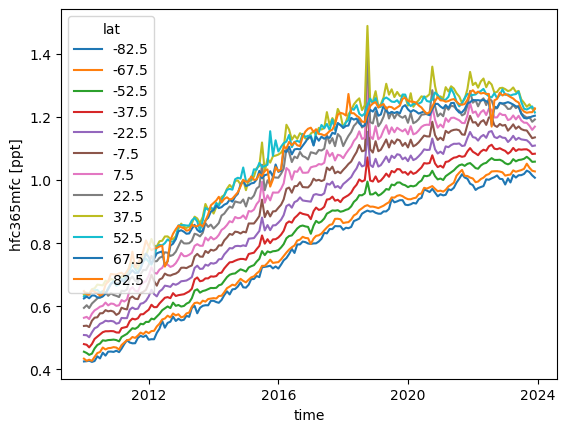

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

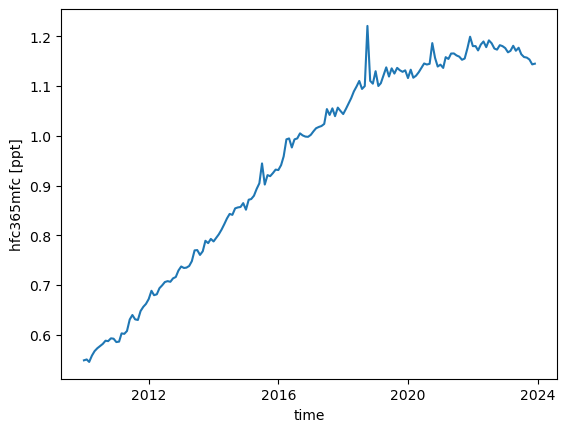

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

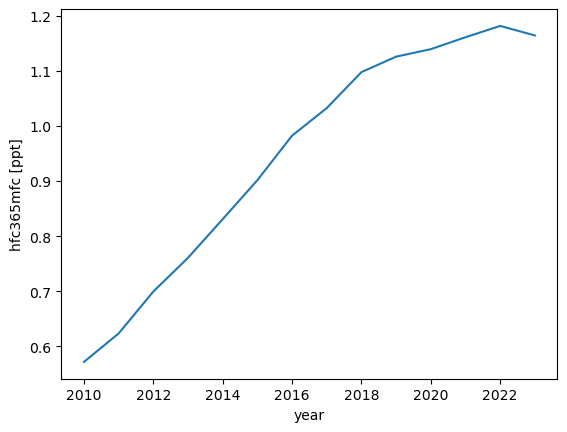

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

Magnitude,[[0.4839666953055328 -0.3979059807932109 0.09696335816807031 0.43483299369378997 -0.3721245922505381 -0.19556264447413518 0.3589185802068437 -0.3141113658997756 0.02733905499062846 -0.03355664755251621 0.006519093263558098 -0.05328709483460302] [0.44425118305041444 -0.2636712682067785 -0.008415690478409595 0.08635405830174424 0.388190883684094 0.09286822464868995 0.051099751111091746 0.6690981526480608 -0.021570204664603777 0.30087442206612686 0.02391338257718775 -0.15622985705185807] [0.35047197555668524 -0.09078207889338569 -0.04201056476986096 -0.17913320919859393 0.3679595956656704 -0.039345988715876655 -0.22888816184707356 -0.1605037907673536 0.02306963670547591 -0.7276318436117074 -0.16803392040284676 -0.24852581269312632] [0.25161976966884064 0.05002660488957039 -0.08359555008702639 -0.29573720921189645 0.13870908578844482 0.03531779455970714 -0.16312679753696283 -0.45421078630632866 0.05331089495936126 0.3931960082599254 0.5691959507222932 -0.32388514490812836] [0.14007285748326093 0.14540154909975442 -0.11175847700968314 -0.2693220475261963 -0.1564084737354819 0.14399191175481604 0.1035390259455096 -0.1526890002859424 -0.04690429650508931 0.33326506213029156 -0.7344777781121091 -0.37717223974155273] [0.028243377039406912 0.23930137325102938 -0.1407722154087446 -0.20236871035978046 -0.46564635156567236 0.19845718670963255 0.3483805137393201 0.35882577316657055 0.0668765475186963 -0.32600349287395114 0.3166269937319722 -0.40475566974540067] [-0.07352213358181597 0.16285455607850322 0.036643947183797036 0.2704575771367013 -0.19725038974038459 -0.5794819027115008 -0.4826216703046719 0.1933012173376699 0.2784451752139347 0.07333895603231998 -0.04300360664899372 -0.4047556697450508] [-0.17857286884742207 0.06125403836476412 0.010654647968409512 0.40655424237756965 0.06943697336611565 0.14104986842850759 -0.09315963114152953 -0.062162090142393864 -0.783331009758056 -0.03548427159966472 0.06763797739517666 -0.3771722397422578] [-0.32961003799531874 0.09723106846795397 -0.016329344995476038 0.3745665032001241 0.453793076631193 0.1318488886205284 0.4198663936748798 -0.16247315225487485 0.4581750072660871 -0.005842331118300444 -0.021885442002329513 -0.3238851449077052] [-0.29760212353629767 -0.36843523647944465 0.6461918752106197 -0.39982931116093395 0.04968440599948794 -0.2727521273913389 0.21259068466123157 0.04006360851358571 -0.11228783853224907 0.006065651552728005 0.01372768814113471 -0.2485258126931473] [-0.22779172924572422 -0.570790248896391 -0.016464425225343523 0.07101760855076723 -0.24480635657437183 0.5503199107179286 -0.4112950988139475 -0.00845431723206118 0.24520412007384407 -0.012249006080737642 -0.017166385877971722 -0.15622985705190406] [-0.2747057875186813 -0.4262908771766004 -0.7279487902198594 -0.16366393405507526 0.05338967523234476 -0.3740216148505086 0.15883379265924255 0.014119522130521938 -0.12224325801446767 0.009734201810416827 0.008345667349284264 -0.0532870948345849]]
Units,ppt
Magnitude,[[-0.2780640406794462 -0.005543856765974914 -0.00980429667619776 0.00046859653545850956 -0.001367145334789844 0.0024080817425598216 0.0011146949956439643 0.0007028191198016324 -0.0002490527676694879 1.9159869476990187e-05 -2.6046127158928885e-05 6.918270996925595e-18] [-0.300272509195684 -0.023473862996819632 -0.023377126038666405 -0.00409116788844313 -0.0022187272653421924 -0.001672734101686392 0.00032573018104638637 -0.00044031772717949427 -9.456904047379185e-05 -7.476953508365648e-06 8.411514874667333e-06 -4.321205594392065e-17] [-0.3333199348130362 0.00634319158260903 -0.0076059834400768415 -0.0011885871448038834 0.002778706014478468 0.0016996662675501156 -0.0002119310096507536 0.0005296007344888197 -0.00015657392242992906 -8.172245911434194e-05 -1.828386513514961e-05 -3.1851030176745933e-17] [-0.3646837204399982 -0.008825429518264738 0.0030785017044088654 -0.0018541387914523322 -0.0021573328195322893 0.0014230326358233758 -0.0026271615319878898 -0.00018359951052600738 -0.0002076500059588252 -3.019896

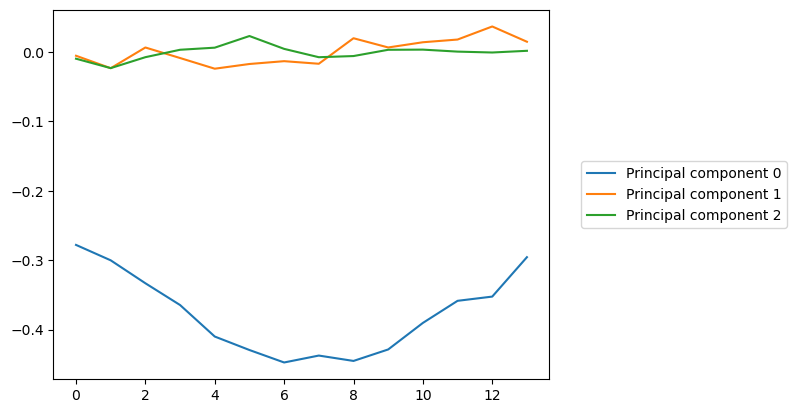

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

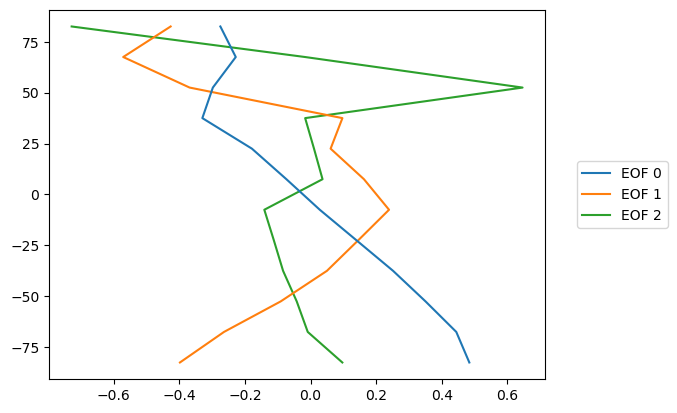

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

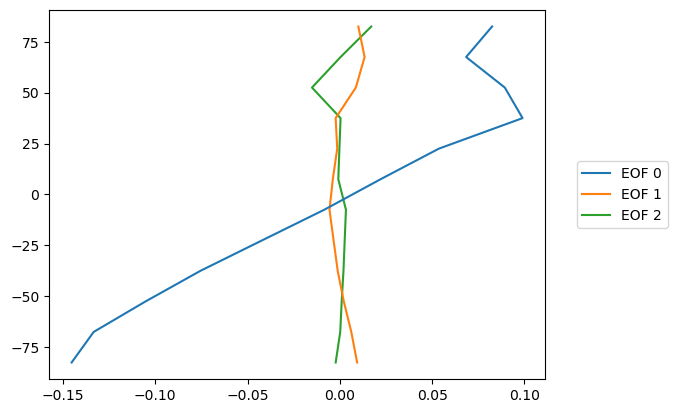

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.4839666953055328] [0.44425118305041444] [0.35047197555668524] [0.25161976966884064] [0.14007285748326093] [0.028243377039406912] [-0.07352213358181597] [-0.17857286884742207] [-0.32961003799531874] [-0.29760212353629767] [-0.22779172924572422] [-0.2747057875186813]]
Units,ppt
Magnitude,[[-0.2780640406794462] [-0.300272509195684] [-0.3333199348130362] [-0.3646837204399982] [-0.410073678580372] [-0.42949284938375903] [-0.4474403477249727] [-0.43747761461762447] [-0.44521955838964705] [-0.4286889183712841] [-0.39045560664695933] [-0.35861699063228525] [-0.35252006726540713] [-0.29574078373534823]]
Units,dimensionless


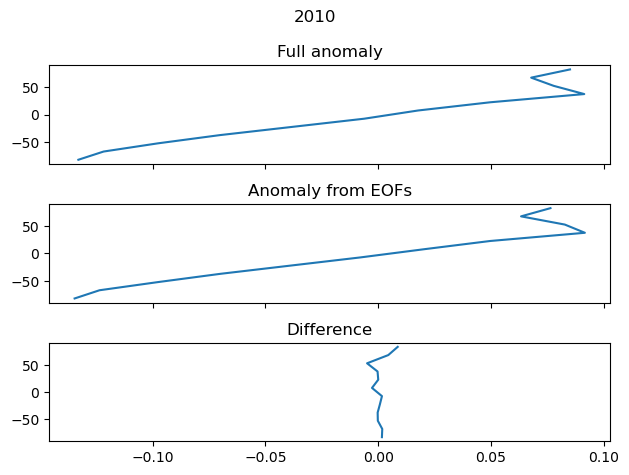

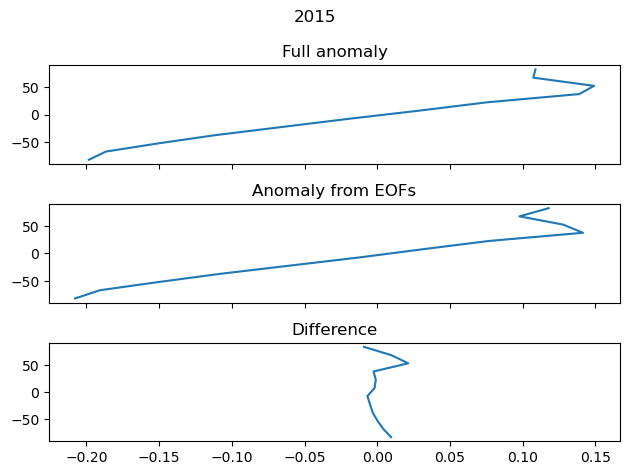

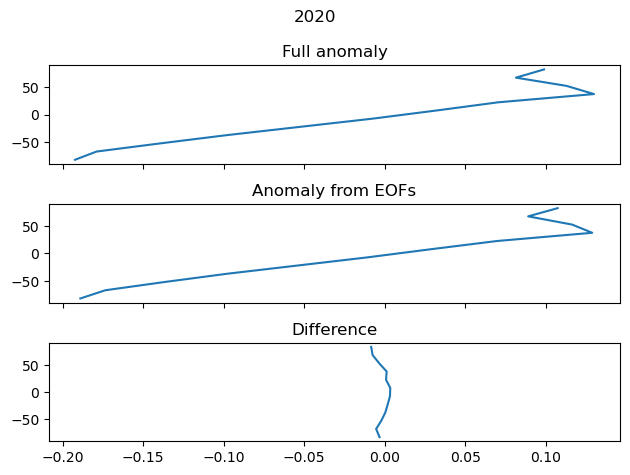

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 168/168 [00:00<00:00, 11026.42it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 168/168 [00:00<00:00, 18639.38it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/168 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 168/168 [00:00<00:00, 19500.83it/s]

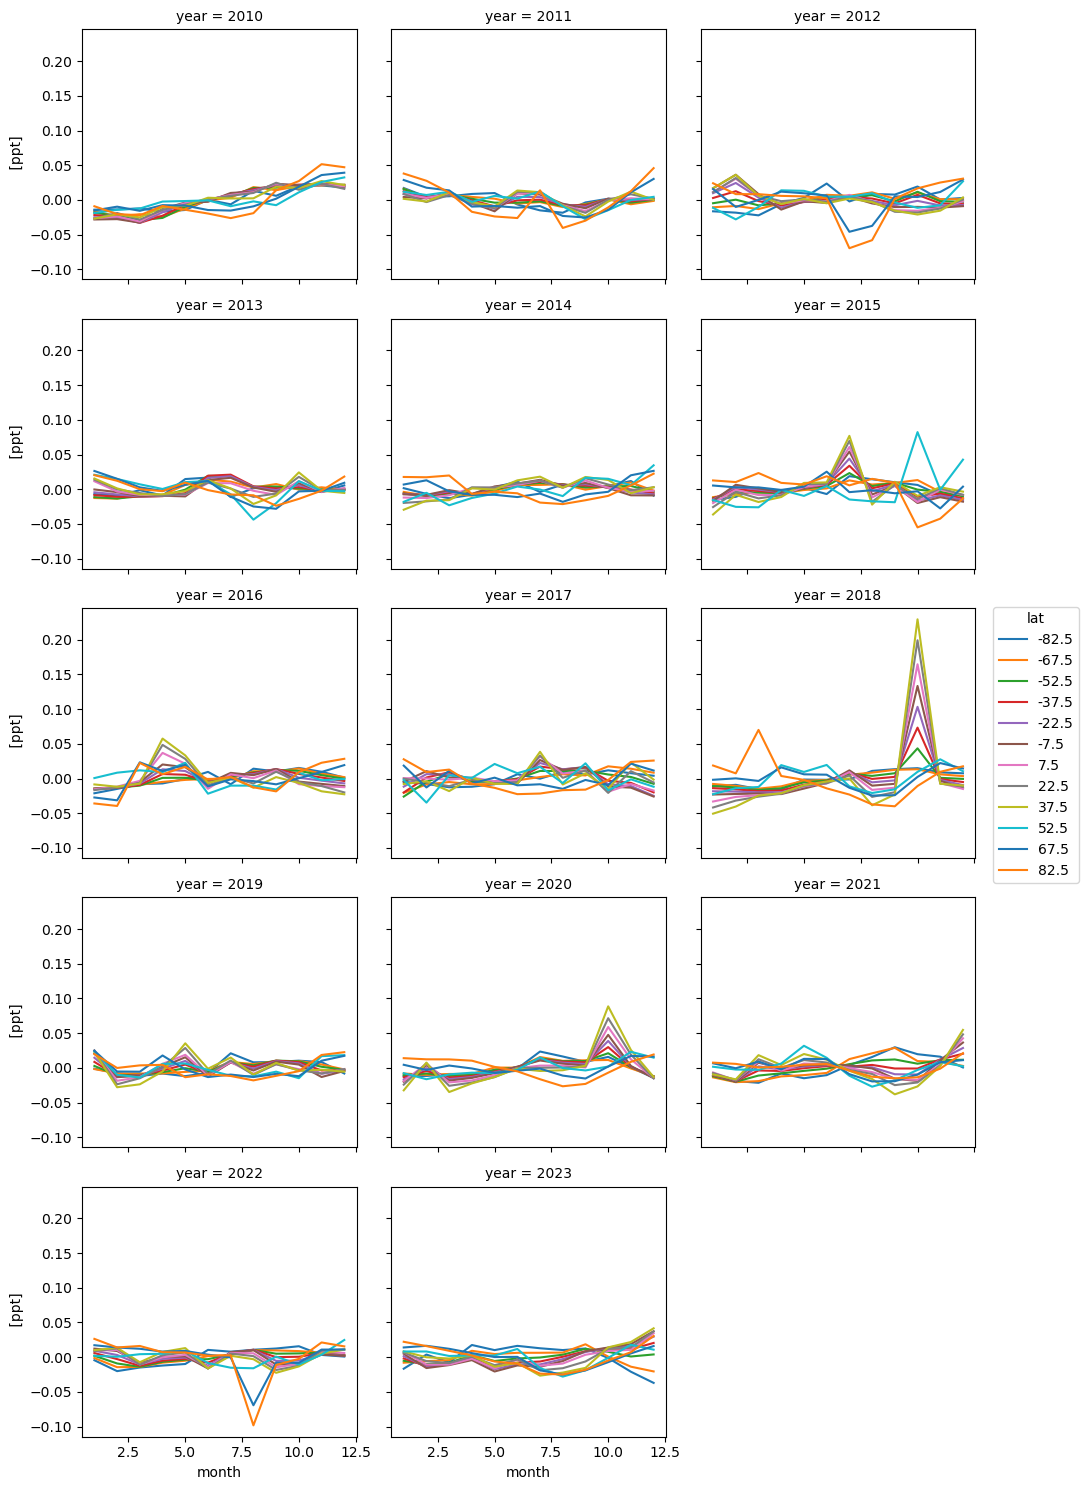

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

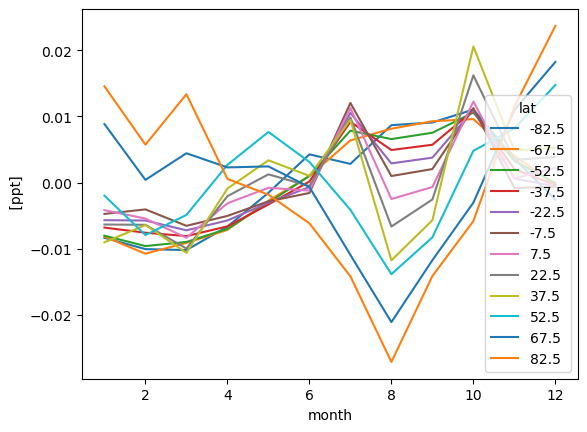

In [22]:
seasonality.plot.line(hue="lat")

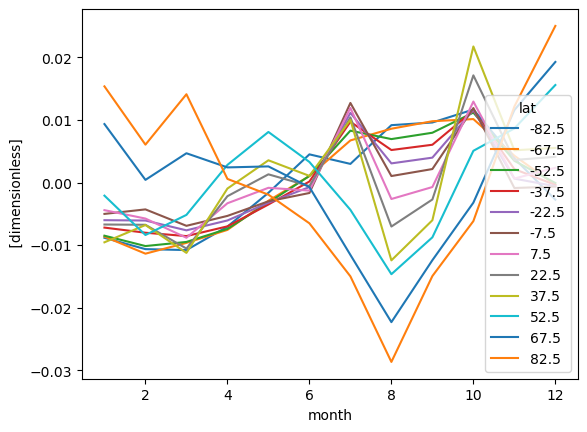

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[0.5718843468169715 0.6234826070156244 0.6995170729072644 0.7606548150388596 0.8307375058197225 0.9014442712217731 0.982154119249432 1.0321576740402103 1.09737229874019 1.1254245533644742 1.139003239395477 1.1606984493041608 1.18116072477494 1.1639005135949592]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.4839666953055328] [0.44425118305041444] [0.35047197555668524] [0.25161976966884064] [0.14007285748326093] [0.028243377039406912] [-0.07352213358181597] [-0.17857286884742207] [-0.32961003799531874] [-0.29760212353629767] [-0.22779172924572422] [-0.2747057875186813]]
Units,ppt
Magnitude,[[-0.2780640406794462] [-0.300272509195684] [-0.3333199348130362] [-0.3646837204399982] [-0.410073678580372] [-0.42949284938375903] [-0.4474403477249727] [-0.43747761461762447] [-0.44521955838964705] [-0.4286889183712841] [-0.39045560664695933] [-0.35861699063228525] [-0.35252006726540713] [-0.29574078373534823]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.008835560152302791 -0.010643589468264004 -0.010792972071364587 -0.00704812239384038 -0.0016472023440100643 0.004496570522853882 0.0029715529496108163 0.009160338333691186 0.009585300895498005 0.011658949506825174 0.0038468326369360643 -0.002752167820391807] [-0.008643970777958395 -0.011368644140578019 -0.009645600664371833 -0.007573026977712522 -0.0029145901848325784 0.0010282890251603677 0.006721855030987221 0.008592109172098907 0.009787718026078767 0.010132732930516489 0.004275442697551689 -0.0003923519175081931] [-0.008497247050977546 -0.010153338330409467 -0.009496457751038084 -0.007411654311186692 -0.0032080966791143673 0.0010496863246438758 0.00828228658761888 0.006935687280114648 0.007949891408597297 0.011167440610868376 0.003465973414132563 -8.415318170613716e-05] [-0.007204329072777872 -0.008022940164506092 -0.00856134698564501 -0.007005101150290374 -0.0035142219782915906 0.000158628558993901 0.00970095402822061 0.005188280456279971 0.006031205842999172 0.011487140887919968 0.0021389826777016537 -0.00039718608386638763] [-0.006020155545191972 -0.006074335469974494 -0.007641184029037089 -0.006063691649302137 -0.0032329357970009146 -0.0007331538876989194 0.01112596742894731 0.0030543101068914373 0.003971185585854634 0.01158295732073687 0.0006175160924122105 -0.0005863788170024201] [-0.005016471297030088 -0.004295973303602473 -0.006920601176157121 -0.005335589648552435 -0.003005147479853398 -0.0016759440966504302 0.012708041540515962 0.0010328367523219429 0.002149482968788901 0.011894551910952079 -0.0008779476092097083 -0.0006571062340444545] [-0.004417814289219467 -0.005760330958349148 -0.008828034132751893 -0.003316364104602796 -0.0008478769918123283 -0.0012938746089148445 0.011910560274033633 -0.0026354222484130277 -0.0007255575994397981 0.012931186975812133 0.000637561776060173 0.002346080344684472] [-0.006712573583775202 -0.0067545325012031915 -0.010552723271641383 -0.0021881764039656934 0.0013050010947619783 -0.0005653450476088323 0.010398819743128182 -0.007034740426397022 -0.0027143415370869018 0.01711676822850908 0.0035971146982616063 0.004104860028171077] [-0.009553737591281706 -0.006791336959242184 -0.011242848222271895 -0.000967095931803965 0.0035478853124551193 0.0010546483246735925 0.010017011683963017 -0.012435018830304123 -0.006029594967665768 0.021731002703756372 0.005144488987642111 0.005524764335530557] [-0.002101210630161636 -0.008388869616081693 -0.005175032104077162 0.002812769255645505 0.008073132434884936 0.003278892155878795 -0.00436675024381471 -0.01464666995581573 -0.008759436397647806 0.0050627554738422375 0.00863733539667018 0.015573188233501874] [0.009335120704822833 0.0004199680631275596 0.004672479606481974 0.0024120123558833734 0.002570430693466399 -0.0007334318358268346 -0.011566429065325972 -0.022306198484904536 -0.012412261871147925 -0.0032205546578684004 0.011570659383870146 0.01925827731543234] [0.01535857843920203 0.006047495901072291 0.014099135156596087 0.0005742067707170357 -0.001941227647366797 -0.006519046156987947 -0.014991307728048566 -0.028662513377865514 -0.014945616775052732 -0.006168036421851725 0.012134818789459899 0.025013607744087868]]
Units,dimensionless
